# Regresión Lineal

### Laboratorio de Datos, IC - FCEN - UBA - Verano 2026



### Nueva librería

Utilizaremos el módulo `scikit-learn` de Python. Para instalarlo, correr:

In [6]:
!pip install scikit-learn

Importamos los módulos de siempre, las herramientas de modelos lineales y las medidas de desempeño del modelo de `scikit-learn`:

In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import seaborn.objects as so

# Herramientas de modelos lineales
from sklearn import linear_model

# Medidas de desempeño
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error

### Modelo de Regresión Lineal

Queremos utilizar un modelo lineal:
$$ Y = \beta_0 + \beta_1 X $$
para intentar predecir valores continuos.

### Visualización

Con lo que hemos visto las clases anteriores, visualizar la recta que mejor aproxima a los datos en el sentido de cuadrados mínimos es relativamente sencillo con `seaborn objects`, ya que `seaborn` calcula automáticamente los valores de $\beta_0$ y $\beta_1$.

Utilizaremos el dataset _tips_ de `seaborn` y analizaremos la relación entre lo que costó la comida y la cantidad de propina.

In [8]:
datos = sns.load_dataset('tips')
datos

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


Visualizamos los datos con `so.Plot` (repasar clase de visualización)

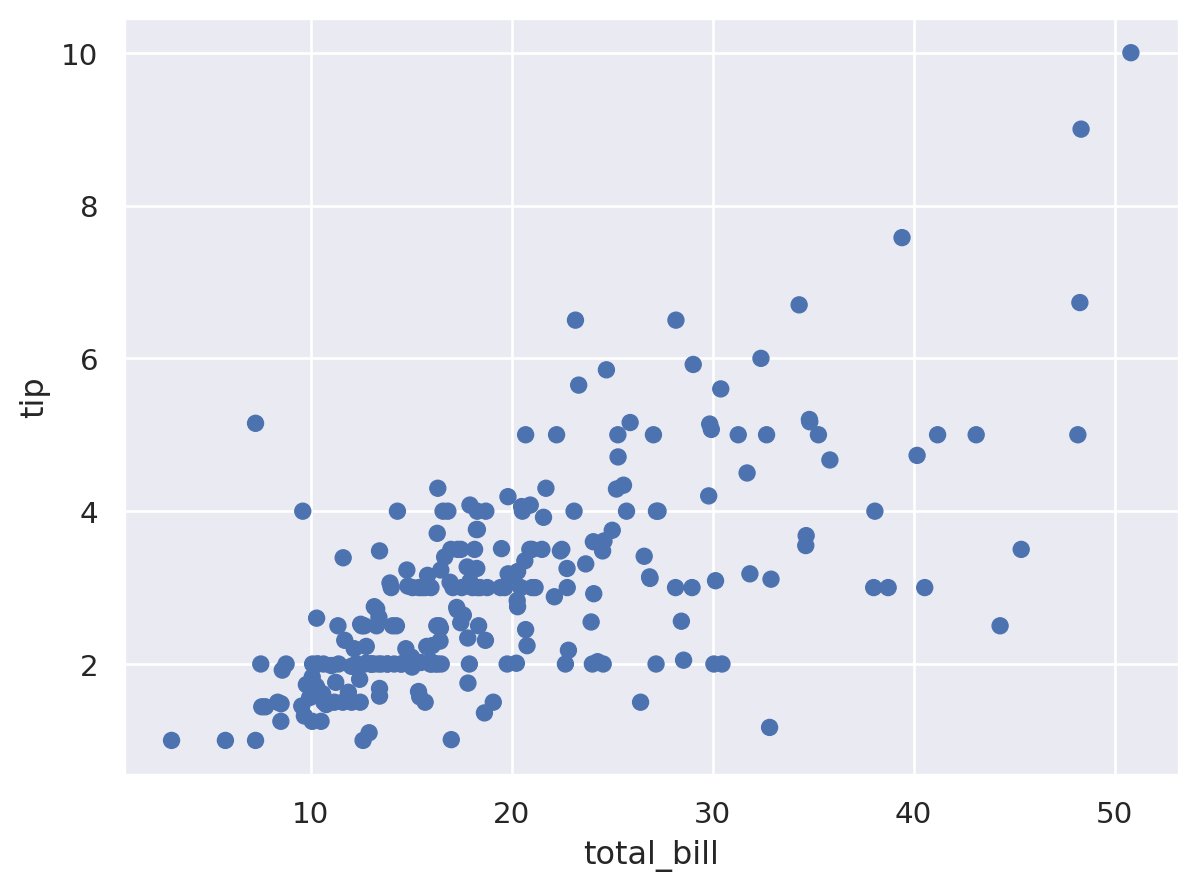

In [9]:
# Graficamos la relacion entre las variables

(
    so.Plot(data=datos, x='total_bill', y='tip')
    .add(so.Dot())
)

Para visualizar la recta de la regresión, agregamos una línea al gráfico (`so.Line()`) junto a `so.PolyFit(1)`:

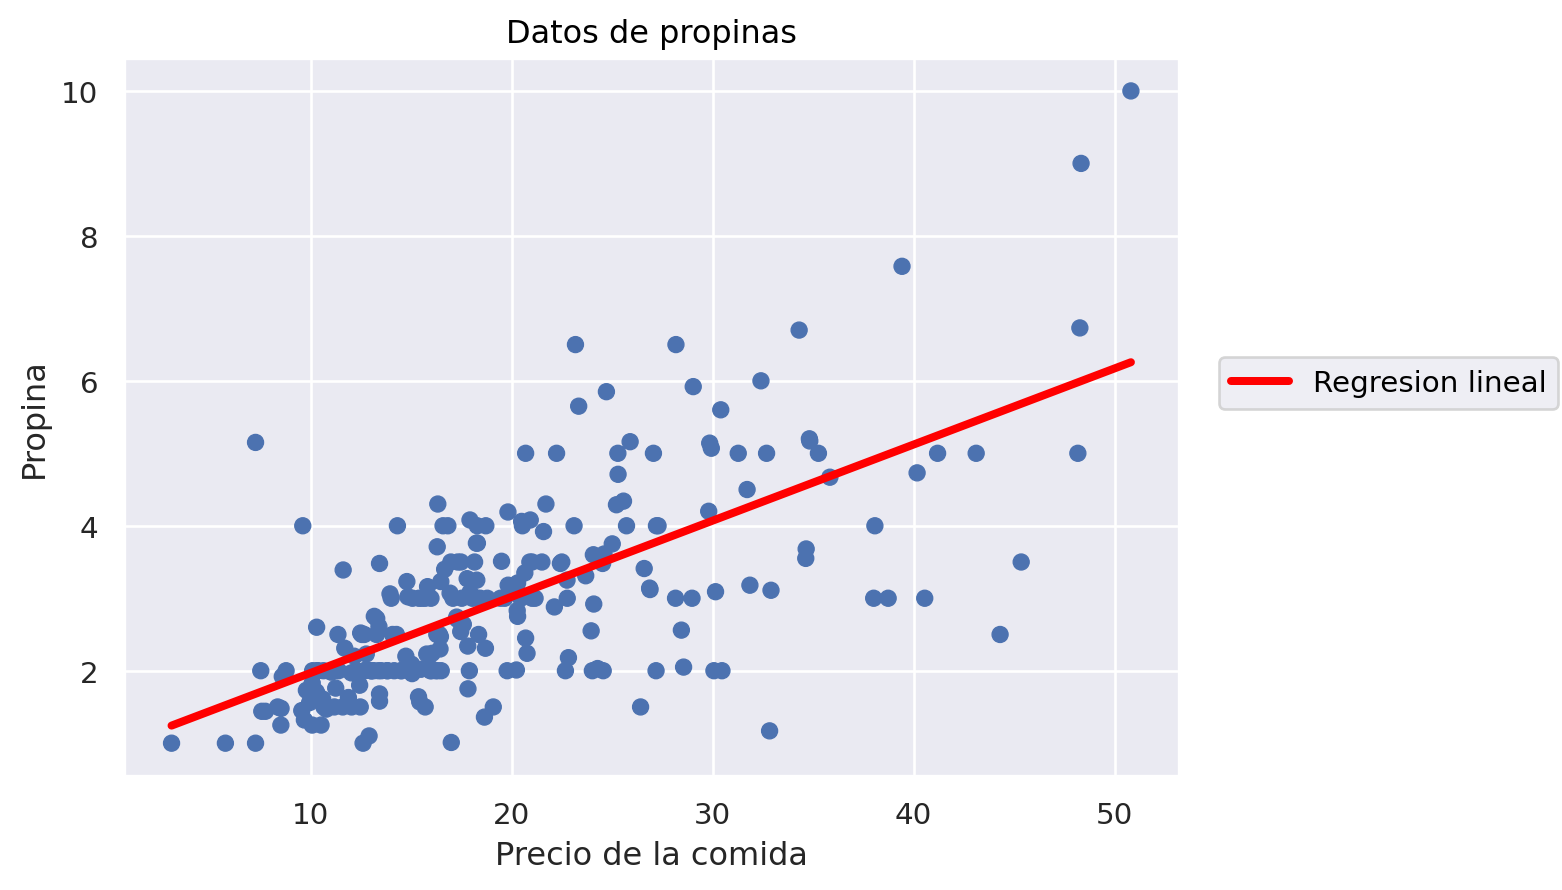

In [10]:
(
    so.Plot(data=datos, x='total_bill', y='tip')
    .add(so.Dot())
    .add(so.Line(color='red', linewidth=3), so.PolyFit(1), label='Regresion lineal')    # Agregamos una etiqueta para la leyenda del grafico
    .label(title='Datos de propinas', x='Precio de la comida', y='Propina')    # Agregamos la leyenda, un titulo y le cambiamos el nombre a los ejes
)

### Cálculo de coeficientes y predicciones

Desafortunamente, `seaborn` no nos devuelve los valores de $\beta_0$ y $\beta_1$, que son importantes en la interpretación del resultado.

Hemos visto que podemos calcular los coeficientes de la regresión lineal como:

 $$
 \begin{array}{rl}
      \hat{\beta}_1 = & \dfrac{\displaystyle\sum_{i=1}^n(x_i - \bar{x})(y_i - \bar{y})}{\displaystyle\sum_{i=1}^n(x_i - \bar{x})^2}  \\[1em]
      \hat{\beta}_0 = & \bar{y} - \hat{\beta}_1\bar{x}
 \end{array}
 $$

 pero también podemos utilizar `scikit-learn`.

Como queremos predecir la propina según el precio de la comida usando una función lineal, la fórmula de Wilkinson es:
$$tip \sim total\_bill$$

In [11]:
# Definimos las variables explicativas X (dataframe) y la variable respuesta y (vector)
X = datos[["total_bill"]]
y = datos["tip"]

**Ejercicio:** Calcular el coeficiente $\hat \beta_1$ y el intercept $\hat \beta_0$ utilizando la magia de Numpy

In [12]:
x = datos["total_bill"]#np.ones((244, 244))
x_raya = x.mean()
y_raya = y.mean()

b1_est = ((X.total_bill-x_raya)*(y-y_raya)).sum()/(((X.total_bill-x_raya)**2).sum())
b0_est = y_raya - b1_est*x_raya

In [13]:
print(b1_est)
print(b0_est)

0.1050245173843534
0.9202696135546726


Lo hacemos ahora con scikit-learn.

In [14]:
# Inicializamos el modelo de regresión.
modelo = linear_model.LinearRegression()

In [15]:
# Realiza el ajuste
modelo.fit(X, y)  # X debe ser una matriz o dataframe, no puede ser un vector o serie.

LinearRegression()

In [16]:
# Para obtener los valores de beta_1 y beta_0 como valores numericos
print("Coeficientes: ", modelo.coef_)
print("Intercept: ", modelo.intercept_)

# La convención es que los atributos que terminan en underscore (_) se aprenden del modelo,
# y los atributos sin underscore son parámetros que le pasamos al modelo.)

Coeficientes:  [0.10502452]
Intercept:  0.9202696135546731


In [17]:
# Para obtener los valores de beta_1 y beta_0 como valores numericos
print("Coeficientes: ", modelo.coef_)
print("Intercept: ", modelo.intercept_)

# La convención es que los atributos que terminan en underscore (_) se aprenden del modelo,
# y los atributos sin underscore son parámetros que le pasamos al modelo.)

Coeficientes:  [0.10502452]
Intercept:  0.9202696135546731


In [18]:
beta0 = modelo.intercept_
beta1 = modelo.coef_[0]  # Como puede haber varios coeficientes, coef_ es un vector y tomamos el primer coeficiente.

In [19]:
vars(modelo)

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['total_bill'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([0.10502452]),
 'rank_': 1,
 'singular_': array([138.77486834]),
 'intercept_': np.float64(0.9202696135546731)}

Entonces, la recta que mejor aproxima a los datos es (redondeando):
$$ Y = 0.92 + 0.105 X$$

Una interpretación que podemos darle a este resultado es que, por cada peso que costó la comida, se dejan de propina 0.105 pesos (o sea, alrededor de 10 centavos)

Con los valores de $\beta_0$ y $\beta_1$ podemos predecir cuanto será la propina según el valor de la comida. Supongamos que queremos predecir la propina que se deja por una cuenta \\$35. Utilizamos el método `predict()` del modelo.

<span style="color:red">**EL MÉTODO .predict() (igual que fit para variables explicativas) SOLO ADMITE ADMITE DATAFRAMES (O MATRICES).**</span>

In [20]:
# Creamos un DataFrame con los valores a predecir
x_nuevo = pd.DataFrame({"total_bill": [35]})

# Aplicamos la fórmula del modelo
modelo.predict(x_nuevo)

array([4.59612772])

In [21]:
# Predict devuelve un vector de predicciones.
# Si queremos solo el valor...
modelo.predict(x_nuevo)[0]

np.float64(4.596127722007041)

También podemos hacer directamente la cuenta porque ya sabemos cuanto valen $\beta_1$ y $\beta_0$:

In [22]:
beta1 * 35 + beta0

np.float64(4.596127722007041)

Podemos predecir varios valores de una:

In [23]:
# Creamos un array con los valores a predecir
x_nuevo = pd.DataFrame({"total_bill": [35, 60, 200]})

# Aplicamos la fórmula del modelo
modelo.predict(x_nuevo)

array([ 4.59612772,  7.22174066, 21.92517309])

Si queremos calcular los valores predichos por el modelo $\hat{y}_i$ para todos nuestros $x_i$:

In [24]:
y_pred = modelo.predict(X)
display(y_pred)

array([2.70463616, 2.00622312, 3.12683472, 3.40725019, 3.5028225 ,
       3.57633966, 1.84133463, 3.74332864, 2.49983836, 2.47253198,
       1.99887141, 4.6234341 , 2.53974767, 2.85587147, 2.47778321,
       3.1866987 , 2.00517288, 2.631119  , 2.70253567, 3.0890259 ,
       2.80230897, 3.05121707, 2.57650625, 5.06033609, 3.00185555,
       2.79075627, 2.32444741, 2.25303074, 3.19930164, 2.98400138,
       1.92325375, 2.84746951, 2.50193885, 3.09322688, 2.78760553,
       3.4471595 , 2.63321949, 2.69833469, 2.88317784, 4.20438627,
       2.60486287, 2.75399769, 2.38431139, 1.93690694, 4.11301494,
       2.84116804, 3.25496464, 4.32306398, 3.91871958, 2.81491191,
       2.23727706, 2.0009719 , 4.57617306, 1.96421332, 3.60469628,
       2.96719746, 4.91225152, 3.69396712, 2.10074519, 5.98980307,
       3.05121707, 2.3706582 , 2.0776398 , 2.84116804, 2.76765087,
       3.02916192, 2.64792292, 1.24269488, 3.0449156 , 2.49668762,
       2.18266431, 2.71303813, 3.74122815, 3.57528941, 2.46728

Graficamos la recta que obtuvimos con la que hizo automáticamente so.Plot

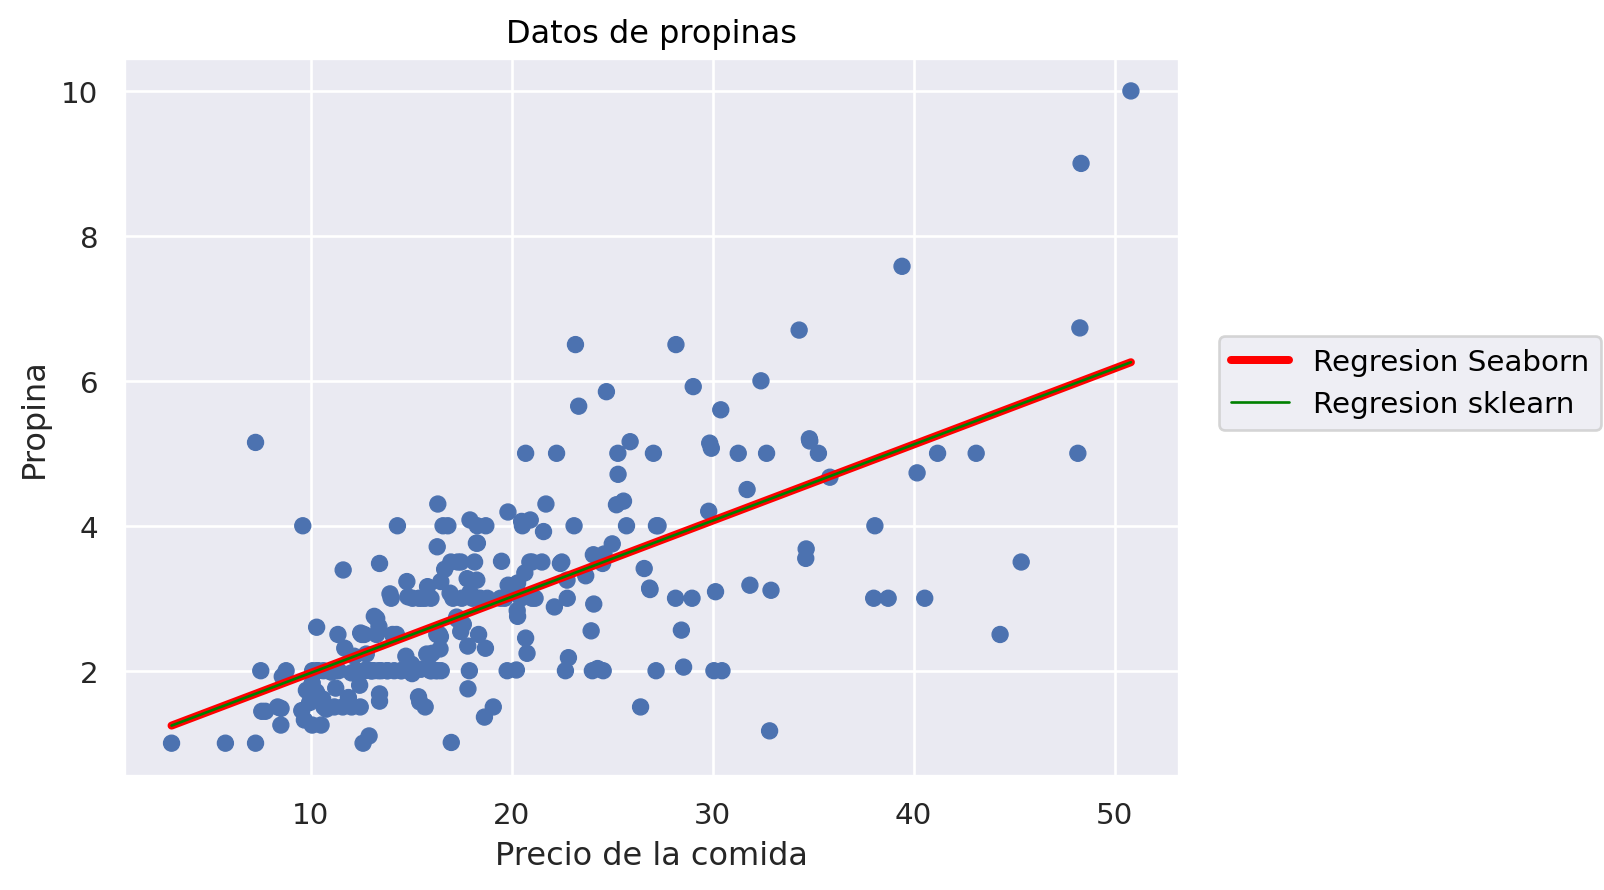

In [25]:
datos["prediccion"] = y_pred

(
    so.Plot(data=datos, x="total_bill")
    .add(so.Dot(), y = "tip")
    .add(so.Line(color="red", linewidth=3), so.PolyFit(1), y = "tip", label="Regresion Seaborn")    # Agregamos una etiqueta para la leyenda del grafico
    .add(so.Line(color="green", linewidth=1), y = "prediccion", label="Regresion sklearn")
    .label(title="Datos de propinas", x="Precio de la comida", y="Propina")    # Agregamos la leyenda, un titulo y le cambiamos el nombre a los ejes
)

### ¿Qué tan bueno es el modelo?

Finalmente, el bueno de `scikit-learn` nos calcula el coeficiente de determinación $R^ 2$.   

In [26]:
modelo.score(X, y)  # El score por default es R^2

# Podemos pasarle los datos que usamos para ajustar el modelo o datos nuevos para evaluar el desempeño del modelo en datos desconocidos.

0.45661658635167657

O utilizando r2_score, con parámetros primero van los datos observados ( $y$ ) y luego los datos predichos ( $\hat{y}$ )

In [27]:
y_pred = modelo.predict(X)
r2_score(datos['tip'], y_pred)

0.45661658635167657

De manera análoga podemos calcular el error cuadrático medio (ECM):

In [28]:
mean_squared_error(datos['tip'], y_pred)

1.036019442011377

Y la raíz del error cuadrático medio:

In [29]:
root_mean_squared_error(datos['tip'], y_pred)

1.0178504025697377

Esto último podría interpretarse (informalmente) como que al usar el modelo para predecir cuánta propina dejo, en
promedio voy a cometer un error en el margen de $\pm 1.01785$ pesos.

**Ejercicios**

1. Responder mediante gráficos en cuál de los siguientes casos considera que el modelo lineal tendrá un mayor $R^2$.
    1. mpg ~ horsepower (en el dataset mpg de sns)
    2. weight ~ horsepower (en el dataset mpg de sns)
    3. Huevos ~ peso  (en el dataset crustaceo_huevos.csv)
2. Ajustar para cada uno de esos casos un modelo lineal, calcular los coeficientes del modelo y el $R^2$.


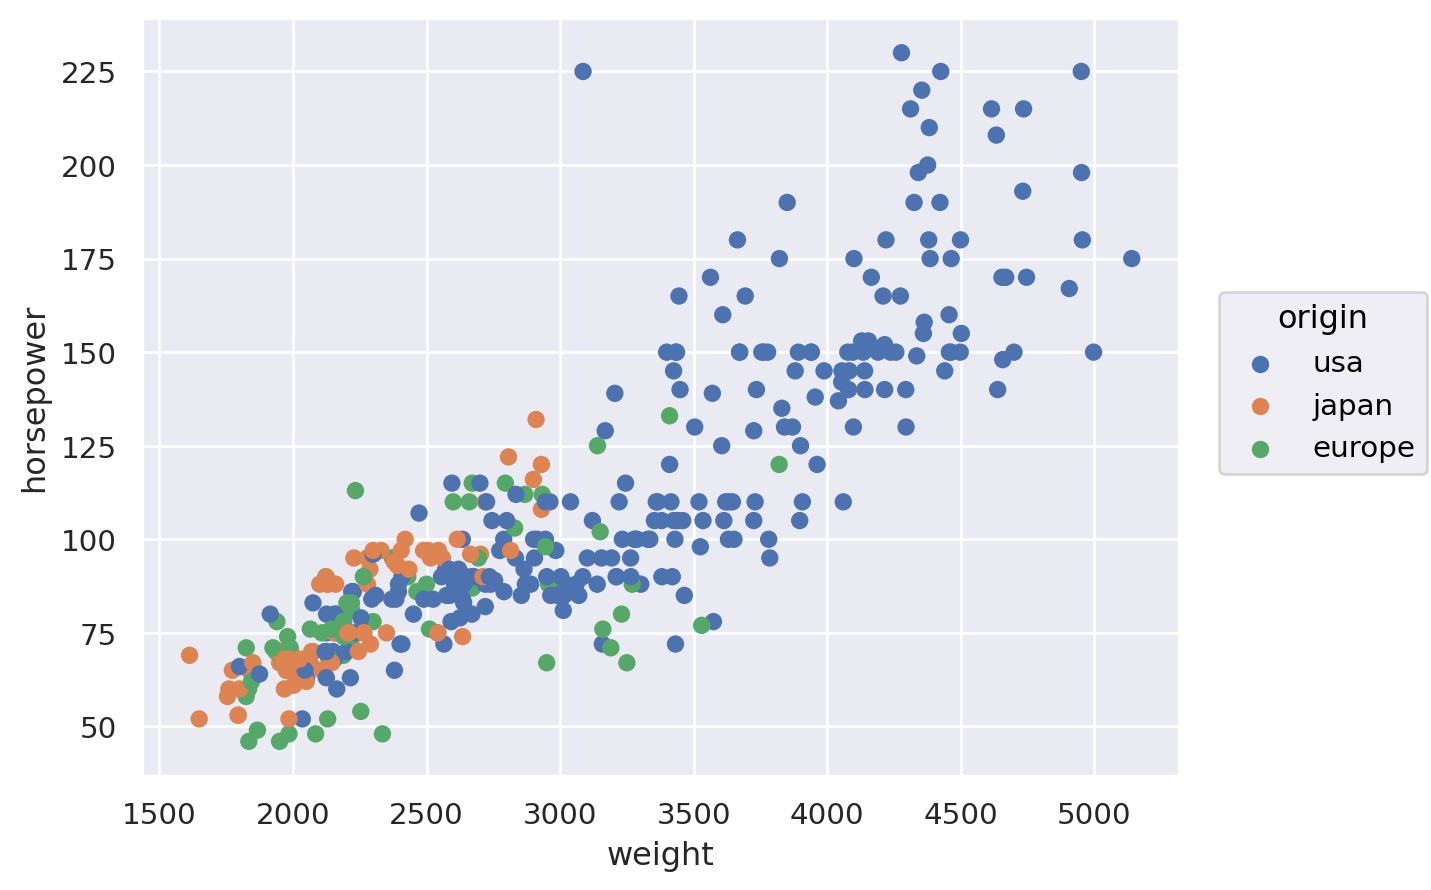

In [30]:
mpg = sns.load_dataset("mpg")
(
    so.Plot(data = mpg, x = "weight", y = "horsepower", color = "origin")
    .add(so.Dot())
)

In [31]:
# El dataset mpg tiene algunas filas con datos faltantes. Podemos eliminarlos utilizando
mpg = mpg.dropna(subset=["horsepower", "weight", "mpg"])

modelo.fit(mpg[["weight"]], mpg.horsepower)

LinearRegression()

In [32]:
print("Coeficientes: ", modelo.coef_)
print("Intercept: ", modelo.intercept_)

Coeficientes:  [0.03917702]
Intercept:  -12.183484703459357


/tmp/ipython-input-2089679440.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mpg["prediccion"] = modelo.predict(mpg[["weight"]])


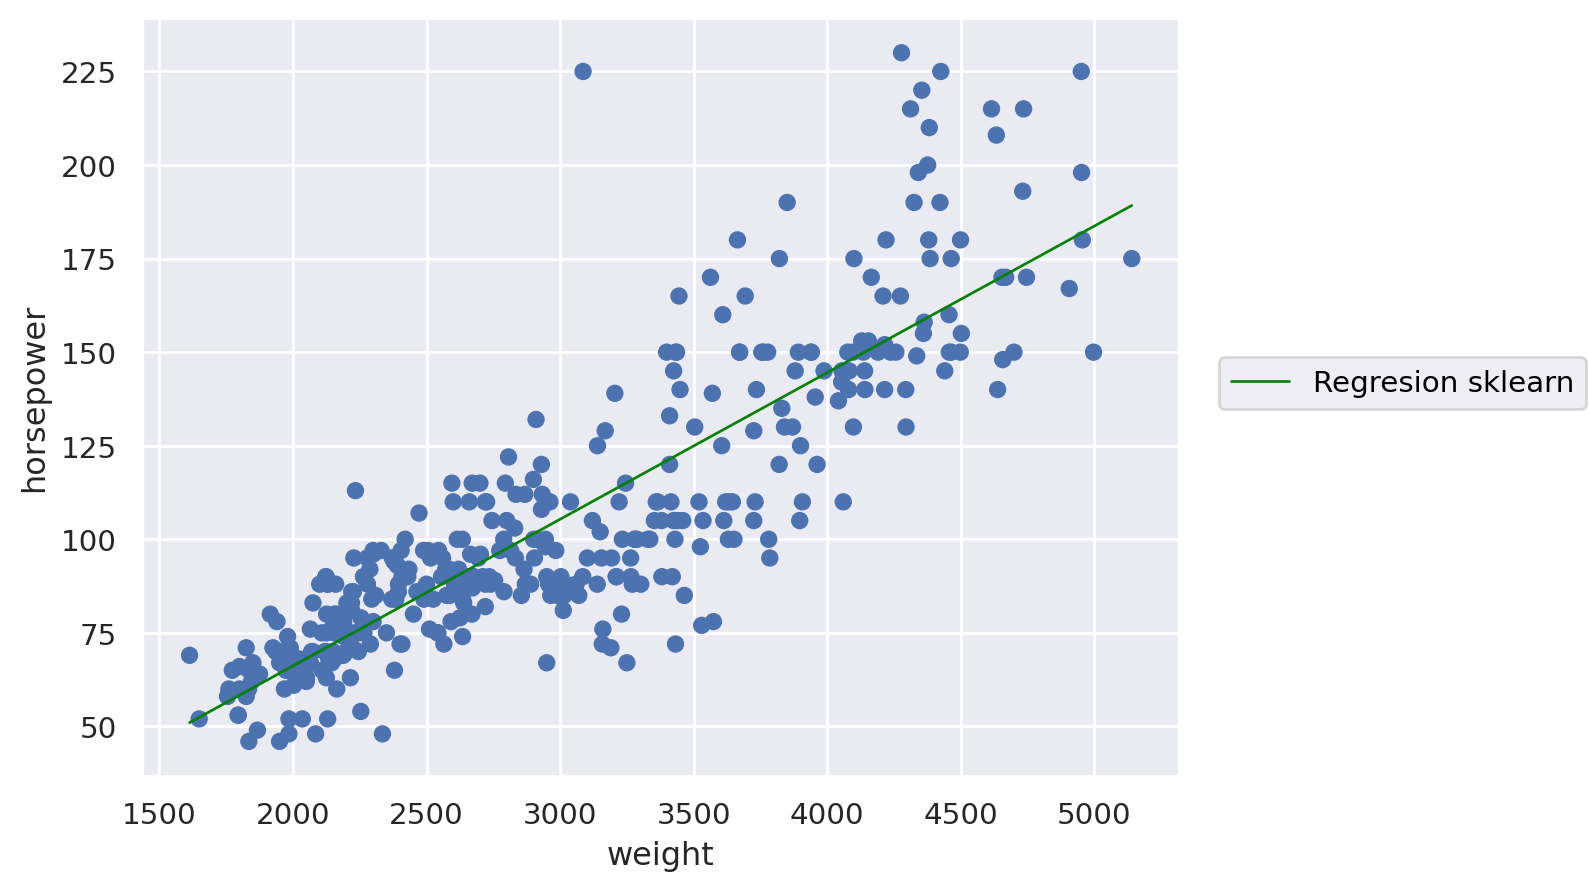

In [33]:
mpg["prediccion"] = modelo.predict(mpg[["weight"]])

(
    so.Plot(data=mpg, x="weight")
    .add(so.Dot(), y = "horsepower")
    #.add(so.Line(color="red", linewidth=3), so.PolyFit(1), y = "horsepower", label="Regresion Seaborn")    # Agregamos una etiqueta para la leyenda del grafico
    .add(so.Line(color="green", linewidth=1), y = "prediccion", label="Regresion sklearn")
    #.label(title="Datos de propinas", x="Precio de la comida", y="Propina")    # Agregamos la leyenda, un titulo y le cambiamos el nombre a los ejes
)

In [34]:
modelo.score(mpg[["weight"]], mpg.horsepower)  # El score por default es R^2

0.74742549968982

In [35]:
horsepower_predict = modelo.predict(mpg[["weight"]])
root_mean_squared_error(mpg.horsepower, horsepower_predict)

19.319731890134328

Era weight ~ horsepower

In [36]:
# El dataset mpg tiene algunas filas con datos faltantes. Podemos eliminarlos utilizando
mpg = mpg.dropna(subset=["horsepower", "weight", "mpg"])

modelo.fit(mpg[["horsepower"]], mpg.weight)

LinearRegression()

In [37]:
print("Coeficientes: ", modelo.coef_)
print("Intercept: ", modelo.intercept_)

Coeficientes:  [19.07816155]
Intercept:  984.500326770238


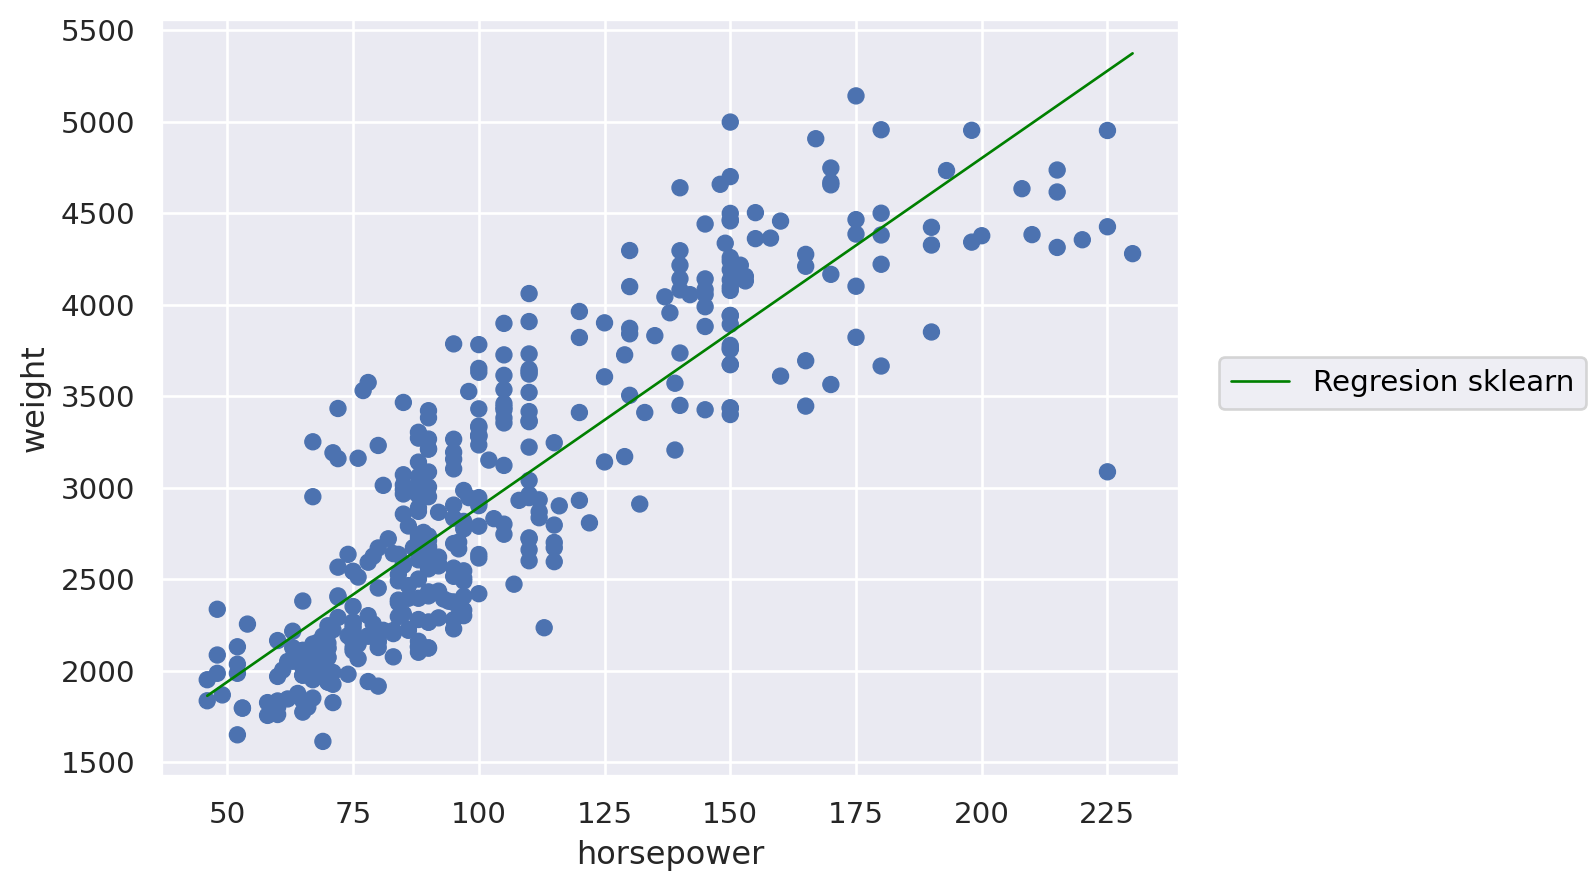

In [38]:
mpg["prediccion"] = modelo.predict(mpg[["horsepower"]])

(
    so.Plot(data=mpg, x="horsepower")
    .add(so.Dot(), y = "weight")
    #.add(so.Line(color="red", linewidth=3), so.PolyFit(1), y = "horsepower", label="Regresion Seaborn")    # Agregamos una etiqueta para la leyenda del grafico
    .add(so.Line(color="green", linewidth=1), y = "prediccion", label="Regresion sklearn")
    #.label(title="Datos de propinas", x="Precio de la comida", y="Propina")    # Agregamos la leyenda, un titulo y le cambiamos el nombre a los ejes
)

In [39]:
modelo.score(mpg[["horsepower"]], mpg.weight)  # El score por default es R^2

0.7474254996898199

In [40]:
weight_predict = modelo.predict(mpg[["horsepower"]])
root_mean_squared_error(mpg.weight, weight_predict)

426.33762545637103

**Ejercicio**

Para el dataset de casos de coronavirus, ajustar una recta al logaritmo de los casos acumulados para los dias 30 a 96.

¿Cuál es la pendiente de la recta?

In [114]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Lic_CsdeDatos/LaboDatos/casos_coronavirus.csv") # DataFrame
df.head()  # Primeras filas del DataFrame

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,fecha,confirmados_Nuevos
0,3-3-2020,1
1,4-3-2020,0
2,5-3-2020,1
3,6-3-2020,6
4,7-3-2020,0


In [141]:
log_cum_casos = np.log(df.confirmados_Nuevos.cumsum()).iloc[30:96]
X = pd.DataFrame(log_cum_casos.index)

In [142]:
model = linear_model.LinearRegression()

In [143]:
model.fit(X, log_cum_casos.values)
print("Coeficientes: ", model.coef_)
print("Intercept: ", model.intercept_)

Coeficientes:  [0.04118087]
Intercept:  6.00081877468408


In [144]:
log_cum_casos_prediccion = model.predict(X)

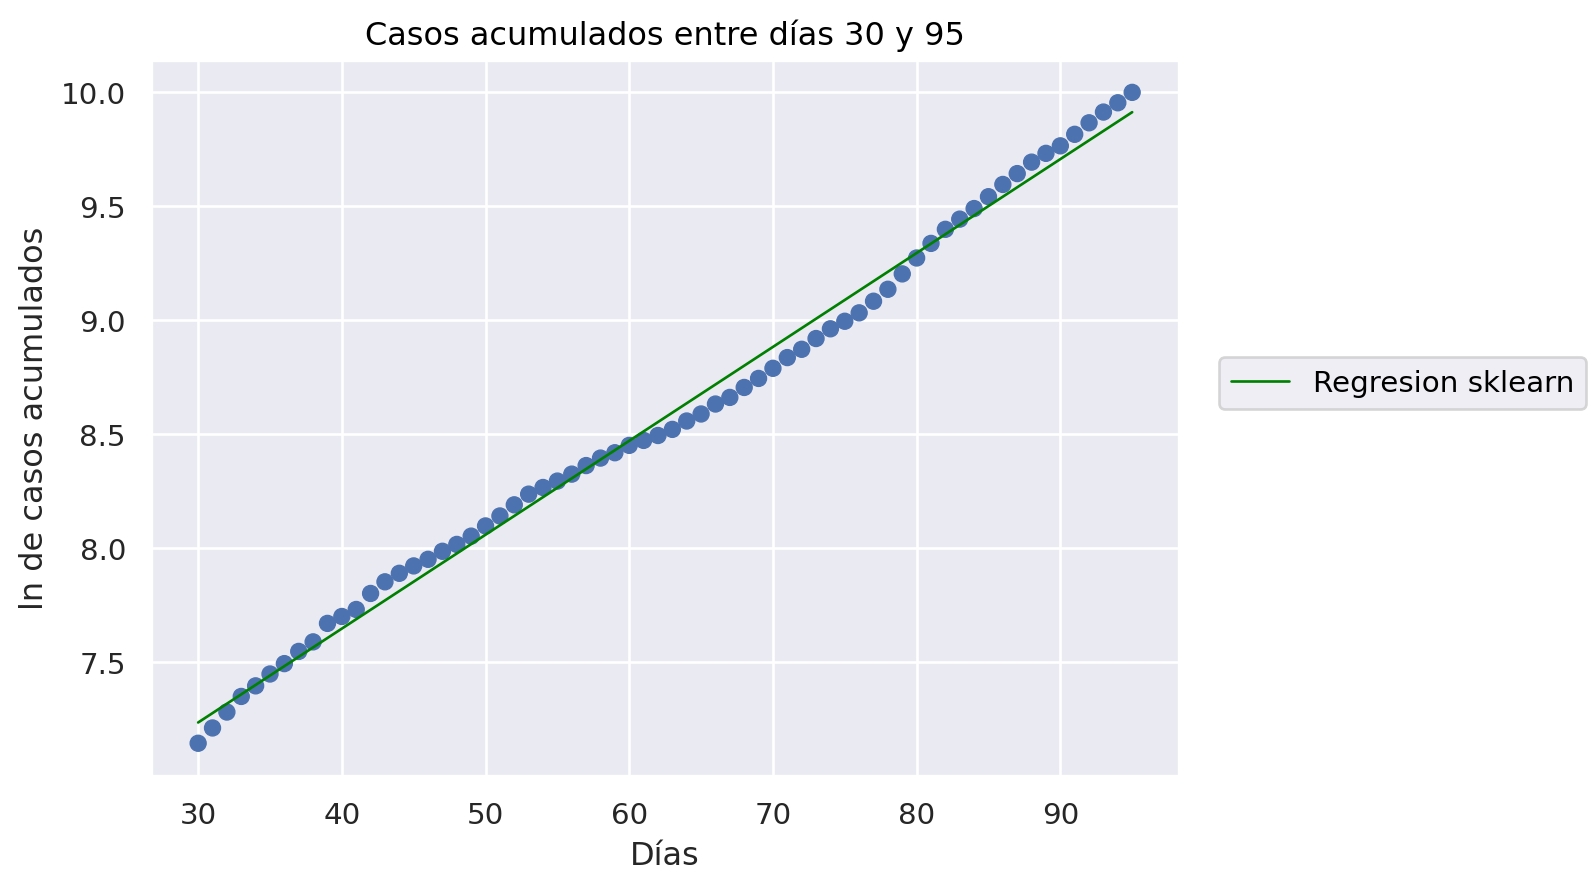

In [145]:
(
  so.Plot(x = log_cum_casos.index)
  .add(so.Dot(), y = log_cum_casos.values)
  .add(so.Line(color="green", linewidth=1), y = log_cum_casos_prediccion, label="Regresion sklearn")
  .label(x = 'Días', y = 'ln de casos acumulados', title = 'Casos acumulados entre días 30 y 95')
)

In [146]:
r2_score(log_cum_casos, log_cum_casos_prediccion)

0.9937224890855145